<a href="https://colab.research.google.com/github/tejuuu-7774/GENAI_collabs/blob/main/MIDSEM_PREP_GENAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA PREPROCESSING


In [ ]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd

In [ ]:
# LOAD THE DATASET
df = pd.read_csv('(12)loan_data.csv')

In [ ]:
# KNOW THE DATASET
df.head()

,Name,Income,Education,Gender,JobStability,LoanApproved
0,Mohan,3200.0,B.tech,Male,1.2,Yes
1,Andrea,3800.0,M.tech,Female,2.5,Yes
2,Joe,4100.0,B.tech,Male,0.8,No
3,Virat,4500.0,Phd,Male,3.6,Yes
4,Abdul,5200.0,M.tech,Male,2.1,Yes


In [ ]:
# KNOW THE DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          8 non-null      object 
 1   Income        7 non-null      float64
 2   Education     8 non-null      object 
 3   Gender        8 non-null      object 
 4   JobStability  8 non-null      float64
 5   LoanApproved  8 non-null      object 
dtypes: float64(2), object(4)
memory usage: 516.0+ bytes


In [ ]:
# KNOW THE DATASET
df.isnull().sum()

,0
Name,0
Income,1
Education,0
Gender,0
JobStability,0
LoanApproved,0


In [ ]:
# KNOW THE DATASET
df.describe()

,Income,JobStability
count,7.000000e+00,8.000000
mean,1.432414e+06,3.475000
std,3.777950e+06,4.747857
min,3.200000e+03,0.800000
25%,3.950000e+03,1.125000
50%,4.500000e+03,1.900000
75%,5.650000e+03,2.775000
max,1.000000e+07,15.000000


In [ ]:
# AS WE OBSERVE IN DESCRIBE() mean >>> 50% -> so fill with MEDIAN
median_val = df['Income'].median()
df['Income'] = df['Income'].fillna(median_val)

In [ ]:
# SORTED IN ASCENDING TO CALCULATE IQR VALUE -> NOT NECCESSARY HERE
df['Income'].sort_values(ascending=True)

,Income
0,3200.0
1,3800.0
2,4100.0
3,4500.0
6,4500.0
4,5200.0
5,6100.0
7,10000000.0


In [ ]:
# REMOVING OUTLIERS
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

df_clean = df[( df['Income'] >= lower_limit ) & (df['Income'] <= upper_limit) ]
df = df_clean

In [ ]:
# LABEL ENCODING ( TEXT -> NUMBERS) for computers to understand it easily
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder();

df['Education'] = le.fit_transform(df['Education'])
df.head()

,Name,Income,Education,Gender,JobStability,LoanApproved
0,Mohan,3200.0,0,Male,1.2,Yes
1,Andrea,3800.0,1,Female,2.5,Yes
2,Joe,4100.0,0,Male,0.8,No
3,Virat,4500.0,2,Male,3.6,Yes
4,Abdul,5200.0,1,Male,2.1,Yes


In [ ]:
# ONE - HOT ENCODING -> So that it creates seperate columns instead of rank based mapping
df = pd.get_dummies(df , columns=['Gender'])
df.head()

,Name,Income,Education,JobStability,LoanApproved,Gender_Female,Gender_Male
0,Mohan,3200.0,0,1.2,Yes,False,True
1,Andrea,3800.0,1,2.5,Yes,True,False
2,Joe,4100.0,0,0.8,No,False,True
3,Virat,4500.0,2,3.6,Yes,False,True
4,Abdul,5200.0,1,2.1,Yes,False,True


In [ ]:
# FEATURE SCALING -> MINMAXSCALING
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# df['Income'] = scaler.fit_transform(df[['Income']])
# df['JobStability'] = scaler.fit_transform(df[['JobStability']])

In [ ]:
# FEATURE SCALING -> STANDARDSCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Income','JobStability']] = scaler.fit_transform(df[['Income' , 'JobStability']])

In [ ]:
df

,Name,Income,Education,JobStability,LoanApproved,Gender_Female,Gender_Male
0,Mohan,-1.465402,0,-0.679258,Yes,False,True
1,Andrea,-0.781548,1,0.725571,Yes,True,False
2,Joe,-0.439620,0,-1.111514,No,False,True
3,Virat,0.016282,2,1.914273,Yes,False,True
4,Abdul,0.814112,1,0.293316,Yes,False,True
5,Riya,1.839893,0,-1.003450,No,True,False
6,Sofia,0.016282,2,-0.138939,Yes,True,False


# LINEAR REGRESSION

In [ ]:
# REQUIRED IMPORTS FOR LINEARREGRESSION
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# FEATURES
X = df[['Income','Education', 'JobStability','Gender_Female','Gender_Male']]
# TARGET
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
y = le_y.fit_transform(df['LoanApproved'])

In [ ]:
# train_test_spliting the data
X_train , X_test , y_train , y_test = train_test_split(X, y ,test_size=0.2 ,random_state=42)

In [ ]:
# MODEL FOR LINEAR REGRESSION
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)
predictions

array([-0.65, -0.85])

# LINEAR REGRESSION - (1) -> HOMEPRICES


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('homeprices.csv')

In [ ]:
# FEATURE
X = df[['area']]
# TARGET
y = df['price']

In [ ]:
# LINEAR MODEL
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
# COEFFICIENT
model.coef_

array([135.78767123])

In [ ]:
# INTERCEPT
model.intercept_

np.float64(180616.43835616432)

In [ ]:
# PREDICTION  - (MANUAL) ---> y = mx + c
y = 135.78767123 * 3800 + 180616.43835616432
y

696609.5890301643

In [ ]:
# INSTEAD OF DOING MANUALLY WE CAN USE THE BELOW ONCE DIRECTLY
model.predict([[3800]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([696609.5890411])

# LINEAR REGRESSION - (2) - KAGGLE CONTEST 1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_train = pd.read_csv('house_train.csv')
df_test = pd.read_csv('house_test.csv')

df_train['Lot_Depth'] = df_train['Lot_Depth'].fillna(df_train['Lot_Depth'].median())

df_train = pd.get_dummies(df_train, columns=['Location'])
df_test = pd.get_dummies(df_test , columns=['Location'])

X = df_train[['Lot_Width','Lot_Depth','Year_Sold','Year_Built','Living_Area','Num_Rooms',
              'Location_Downtown','Location_Rural','Location_Suburb']]

y = df_train['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# RESIDUALS
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print(mse)

1221986527278.04


In [ ]:
df_train.describe()

,ID,Lot_Width,Lot_Depth,Year_Sold,Year_Built,Living_Area,Num_Rooms,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,1000.500000,86.184000,85.324500,2019.956000,1995.939500,2855.676500,4.977000,2.310834e+06
std,577.494589,37.372256,34.472299,3.136875,14.735108,1196.761125,2.001118,1.781685e+06
min,1.000000,20.000000,20.000000,2015.000000,1966.000000,801.000000,2.000000,4.741000e+05
25%,500.750000,54.000000,58.000000,2017.000000,1983.000000,1837.000000,3.000000,1.414488e+06
50%,1000.500000,87.500000,87.000000,2020.000000,1996.000000,2808.500000,5.000000,2.020550e+06
75%,1500.250000,118.000000,110.250000,2023.000000,2008.000000,3865.000000,7.000000,2.679952e+06
max,2000.000000,149.000000,149.000000,2025.000000,2025.000000,4999.000000,8.000000,2.420700e+07


# LOGISTIC REGRESSION

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train

,id,Input_A,Input_B,Target
0,0,-1.107048,13211.546898,1
1,1,-1.502288,197302.006169,1
2,2,-0.452942,-188985.312052,0
3,3,-0.832504,43162.085636,1
4,4,1.237355,-133618.041882,0
...,...,...,...,...
1235,1235,-2.214566,186738.199920,1
1236,1236,1.230224,135920.914254,1
1237,1237,-0.864834,-46257.984590,0
1238,1238,-2.393653,-173596.062344,1


In [ ]:
X = train[['Input_A' , 'Input_B']]
y = train['Target']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 ,random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train , y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test , y_pred)
mse

0.14516129032258066

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test , y_pred)
accuracy

0.8548387096774194

# DECISION TREE CLASSIFIER

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('SUV_data.csv')
df.head()

,Age,Salary,Purchased
0,56,45342,1
1,46,57157,1
2,32,87863,1
3,25,72083,0
4,38,85733,1


In [ ]:
X = df[['Age','Salary']]
y = df['Purchased']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train , y_train)

DecisionTreeClassifier()

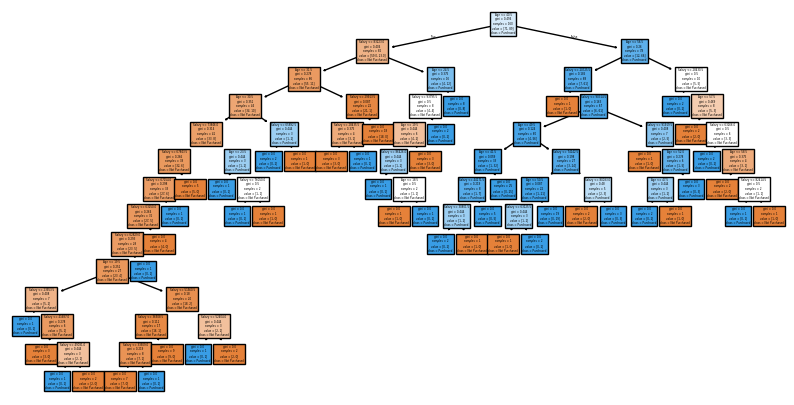

In [ ]:
plt.figure(figsize=(10,5))

plot_tree(model,
          feature_names=['Age','Salary'],
          class_names=['Not Purchased','Purchased'],
          filled=True)
plt.show()

In [ ]:
y_pred = model.predict(X_train)
accuracy_train = accuracy_score(y_train , y_pred)
accuracy_train

1.0

In [ ]:
y_pred = model.predict(X_test)
accuracy_test = accuracy_score(y_test , y_pred)
accuracy_test

0.8

In [ ]:
# OVERFITTING IS VIEWED -> TRAIN = 1.0 AND TEST = 0.8 difference is 0.2

In [ ]:
# # Hyperparamters
# model = DecisionTreeClassifier(max_depth=2)
# model.fit(X_train , y_train)

In [ ]:
# model = DecisionTreeClassifier(max_depth=2 , min_samples_split=2 , min_samples_leaf=1)
# model.fit(X_train , y_train)

In [ ]:
param_grid = {
    'max_depth': [2,3,4,5],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,5]
}

model = DecisionTreeClassifier()

grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

y_pred = grid.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred)
print(accuracy_test)

y_pred = grid.predict(X_train)
accuracy_train = accuracy_score(y_train , y_pred)
print(accuracy_train)

{'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.8
0.83125


# Neural Networks IMDB



In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

In [ ]:
def vectorize(sequences , dimension=1000):
  results = np.zeros((len(sequences) , dimension))
  for i , seq in enumerate(sequences):
    results[i, seq] = 1
  return results

X_train = vectorize(X_train, dimension=10000)
X_test = vectorize(X_test, dimension=10000)

In [ ]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(10000,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7300 - loss: 0.5903 - val_accuracy: 0.8792 - val_loss: 0.3341
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9080 - loss: 0.2739 - val_accuracy: 0.8904 - val_loss: 0.2799
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9384 - loss: 0.1864 - val_accuracy: 0.8900 - val_loss: 0.2782
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9573 - loss: 0.1389 - val_accuracy: 0.8832 - val_loss: 0.2985
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9636 - loss: 0.1180 - val_accuracy: 0.8810 - val_loss: 0.3206


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8750 - loss: 0.3363
Accuracy: 0.8751199841499329


# RNN MODEL TRAINING (NEURAL NETWORKS)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN , Dense , Embedding

In [ ]:
# --> Setup data
train_sentences = [
    'The movie was truly amazing and exciting',
    'I absolutely loved the delicious food',
    'The best day ever',
    'This is the worst experience ever',
    'The service was terrible and very slow',
    'I really hated the boring movie'
]

In [ ]:
train_labels = np.array([1,1,1,0,0,0])

In [ ]:
# 2. The pipeline
# Tokenize and Integer encoding
# OOV -> Out of Vocabulary
tokenizer = Tokenizer(num_words=100 , oov_token='<OOV>')
tokenizer.fit_on_texts(train_sentences)
sequences = tokenizer.texts_to_sequences(train_sentences)

In [ ]:
# Padding the lengths of integers
max_length = 8
padded_data = pad_sequences(sequences, maxlen=max_length , padding='post')

In [ ]:
print("Word : ", tokenizer.word_index)
print("Padded data : ",padded_data)

In [ ]:
# THE MAIN MODEL
model = Sequential()

In [ ]:
model.add(Embedding(input_dim=100 , output_dim=8))

In [ ]:
model.add(SimpleRNN(16))

In [ ]:
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy' , optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(padded_data, train_labels, epochs=50)

In [ ]:
# PREDICTING
test_text = ["I loved the exciting movie" , "The food was terrible"]
test_seq = tokenizer.texts_to_sequences(test_text)
test_pad = pad_sequences(test_seq , maxlen=max_length , padding='post')
print("\n--- TEST RESULTS ---")
preds = model.predict(test_pad)
print("Predictions:", preds)